In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)


def generate_synthetic_contribution_features(n: int = 60) -> pd.DataFrame:
    """
    workload/task/meeting 3피처를 0~100 스케일의 현실적인 팀원 분포로 합성한다.
    실 프로젝트(project_id=1)는 팀원 4명뿐이라 그 데이터만으로 PCA/엔트로피 가중치를
    산출하면 분산 추정 자체가 불안정하다(워크로드 스코어의 IsolationForest가 소표본에서
    불안정했던 것과 같은 문제) - 표본을 보강해서 가중치를 산출한다.
    """
    workload = np.clip(np.random.normal(loc=85, scale=15, size=n), 0, 100)
    task = np.clip(np.random.normal(loc=75, scale=20, size=n), 0, 100)
    meeting = np.clip(np.random.normal(loc=80, scale=18, size=n), 0, 100)
    return pd.DataFrame({"workload": workload, "task": task, "meeting": meeting})


features_df = generate_synthetic_contribution_features()
features_df.describe()

,workload,task,meeting
count,60.000000,60.000000,60.000000
mean,82.053107,73.997584,79.990899
std,12.541612,17.127383,15.068784
min,55.604948,22.605098,51.065302
25%,74.685212,65.303601,65.754934
50%,81.550651,74.387744,84.137423
75%,91.089281,82.444795,94.096489
max,100.000000,100.000000,100.000000


In [2]:
import httpx

# 로컬에 docker compose 스택이 떠 있어야 함 (backend-fastapi:8000)
try:
    resp = httpx.post(
        "http://localhost:8000/ai/score/contribution", params={"project_id": 1}, timeout=10
    )
    resp.raise_for_status()
    real_members = resp.json()["data"]["members"]
    real_df = pd.DataFrame(
        [
            {
                "workload": m["workload_component"],
                "task": m["task_component"],
                "meeting": m["meeting_component"],
            }
            for m in real_members
        ]
    )
    print(f"실 데이터 {len(real_df)}건 병합")
    features_df = pd.concat([features_df, real_df], ignore_index=True)
except Exception as e:
    print(f"실 데이터 조회 실패(합성 데이터만 사용): {e}")

features_df.shape

실 데이터 조회 실패(합성 데이터만 사용): Client error '404 Not Found' for url 'http://localhost:8000/ai/score/contribution?project_id=1'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404


(60, 3)

In [3]:
def entropy_weights(df: pd.DataFrame) -> dict[str, float]:
    """
    표준 엔트로피 가중법: 각 피처 열의 정보량(엔트로피)이 낮을수록(=팀원 간 변별력이
    클수록) 높은 가중치를 준다. 라벨이 필요 없는 비지도 방법.
    """
    eps = 1e-9
    proportions = df / (df.sum(axis=0) + eps)
    n = len(df)
    entropy = -(proportions * np.log(proportions + eps)).sum(axis=0) / np.log(n)
    diversification = 1 - entropy
    weights = diversification / diversification.sum()
    return weights.to_dict()


entropy_result = entropy_weights(features_df)
entropy_result

{'workload': 0.20161002031229727,
 'task': 0.4911049112282618,
 'meeting': 0.307285068459441}

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def pca_weights(df: pd.DataFrame) -> dict[str, float]:
    """1주성분의 절댓값 로딩을 정규화해서 가중치로 쓴다."""
    scaled = StandardScaler().fit_transform(df)
    pca = PCA(n_components=1)
    pca.fit(scaled)
    loadings = np.abs(pca.components_[0])
    weights = loadings / loadings.sum()
    return dict(zip(df.columns, weights)), pca.explained_variance_ratio_[0]


pca_result, explained_variance = pca_weights(features_df)
print(pca_result, f"설명 분산 비율: {explained_variance:.3f}")

{'workload': np.float64(0.23024660103723962), 'task': np.float64(0.3825669159101923), 'meeting': np.float64(0.3871864830525681)} 설명 분산 비율: 0.430


C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:14: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:14: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:14: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:14: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:14: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_29104\3995300280.py:15: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from f

C:\AI-projects\work-flow\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\AI-projects\work-flow\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\AI-projects\work-flow\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\AI-projects\work-flow\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\AI-projects\work-flow\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fi

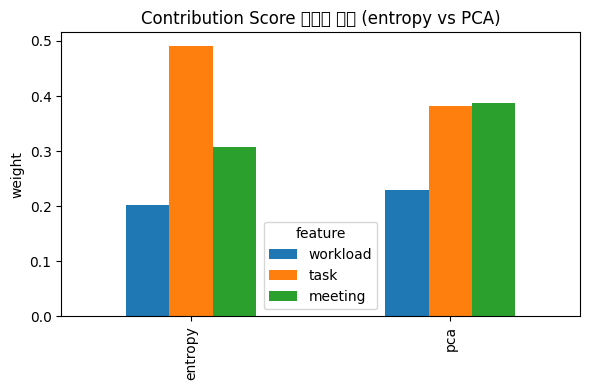

In [5]:
import os

import matplotlib.pyplot as plt

os.makedirs("../App/output/contribution_score", exist_ok=True)

methods_df = pd.DataFrame({"entropy": entropy_result, "pca": pca_result}).T

fig, ax = plt.subplots(figsize=(6, 4))
methods_df.plot(kind="bar", ax=ax)
ax.set_title("Contribution Score 가중치 비교 (entropy vs PCA)")
ax.set_ylabel("weight")
ax.legend(title="feature")
plt.tight_layout()
plt.savefig("../App/output/contribution_score/weight_comparison.png")
plt.show()

In [6]:
# 극단적으로 한 피처에 가중치가 쏠리면(0.9 이상) 균등 평균으로 폴백 - 의사결정 로직을 코드로 남김
def choose_final_weights(entropy_w: dict, pca_w: dict, explained_variance: float) -> dict:
    if explained_variance < 0.5:
        # 1주성분이 전체 분산의 절반도 설명 못하면 PCA 근거가 약하다고 보고 엔트로피 채택
        chosen, method = entropy_w, "entropy"
    else:
        chosen, method = pca_w, "pca"

    if max(chosen.values()) >= 0.9:
        chosen = {k: 1 / 3 for k in chosen}
        method = "equal (fallback - 한 피처 쏠림)"

    print(f"선택된 방법: {method}")
    return chosen


final_weights = choose_final_weights(entropy_result, pca_result, explained_variance)
final_weights

선택된 방법: entropy


{'workload': 0.20161002031229727,
 'task': 0.4911049112282618,
 'meeting': 0.307285068459441}